In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load cleaned data
df = pd.read_csv("../data/cleaned_data.csv")
# 2. check column names
print(df.columns)
df.head()

Index(['id_in_session', 'code', 'index_in_pages', 'current_page_name',
       'time_started', 'payoff', 'consent', 'treatment', 'age_temp', 'gender',
       ...
       'mean_prob_rep_temp', 'mean_prob_rep', 'mean_prob_dem_temp',
       'mean_prob_dem', 'mean_prob_net', 'mean_prob_net_mean',
       'mean_prob_net_sd', 'mean_prob_net_z', 'out_of_range_q',
       'out_of_range'],
      dtype='str', length=331)


,id_in_session,code,index_in_pages,current_page_name,time_started,payoff,consent,treatment,age_temp,gender,...,mean_prob_rep_temp,mean_prob_rep,mean_prob_dem_temp,mean_prob_dem,mean_prob_net,mean_prob_net_mean,mean_prob_net_sd,mean_prob_net_z,out_of_range_q,out_of_range
0,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
1,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
2,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,0.7,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
3,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,0.516667,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
4,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0


In [3]:
print([col for col in df.columns if "party" in col.lower()])
print([col for col in df.columns if "strength" in col.lower() or "strong" in col.lower() or "pt" in col.lower()])

['party', 'net_party_temp', 'net_party', 'abs_net_party', 'pro_party', 'anti_party', 'pro_party_str', 'guess_z_party', 'mean_guess_z_party']
['good_news_strength']


In [4]:
df["mean_prob_net"] = pd.to_numeric(df["mean_prob_net"], errors="coerce")
df["good_news_strength"] = pd.to_numeric(df["good_news_strength"], errors="coerce")

df["group"] = pd.Series(pd.NA, index=df.index, dtype="object")

df.loc[
    (df["party"] == "Republican") & (df["good_news_strength"] >= 0.5),
    "group"
] = "Anti-Party, Partisans"

df.loc[
    (df["party"] == "Republican") & (df["good_news_strength"] < 0.5),
    "group"
] = "Anti-Party, Moderates"

df.loc[
    df["party"] == "Independent",
    "group"
] = "Neutral, All Subjects"

df.loc[
    (df["party"] == "Democrat") & (df["good_news_strength"] < 0.5),
    "group"
] = "Pro-Party, Moderates"

df.loc[
    (df["party"] == "Democrat") & (df["good_news_strength"] >= 0.5),
    "group"
] = "Pro-Party, Partisans"

print(df["group"].value_counts(dropna=False))



group
<NA>                     12831
Pro-Party, Moderates       351
Neutral, All Subjects      340
Anti-Party, Moderates      147
Pro-Party, Partisans       109
Anti-Party, Partisans       40
Name: count, dtype: int64


C:\Users\hany5\AppData\Local\Temp\ipykernel_40624\335819870.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["group"] = pd.Series(pd.NA, index=df.index, dtype="object")


In [5]:
group_order = [
    "Anti-Party, Partisans",
    "Anti-Party, Moderates",
    "Neutral, All Subjects",
    "Pro-Party, Moderates",
    "Pro-Party, Partisans"
]

In [6]:
plot_df = df.dropna(subset=["group", "mean_prob_net"]).copy()

plot_df


,id_in_session,code,index_in_pages,current_page_name,time_started,payoff,consent,treatment,age_temp,gender,...,mean_prob_rep,mean_prob_dem_temp,mean_prob_dem,mean_prob_net,mean_prob_net_mean,mean_prob_net_sd,mean_prob_net_z,out_of_range_q,out_of_range,group
9,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,I have read the above information and would li...,SND,35.0,Male,...,0.516667,NaN,0.700000,-0.183333,-0.06448,0.184348,-0.644722,0,0,"Neutral, All Subjects"
17,100,01enbsyt,155,Results,2018-06-25 15:31:19.463167+00:00,0,I have read the above information and would li...,PND,71.0,Female,...,0.375000,NaN,0.500000,-0.125000,-0.06448,0.184348,-0.328292,0,0,"Neutral, All Subjects"
30,159,01hil87c,155,Results,2018-06-25 18:36:51.529798+00:00,0,I have read the above information and would li...,SNG,35.0,Male,...,0.466667,NaN,0.533333,-0.066667,-0.06448,0.184348,-0.011861,0,0,"Neutral, All Subjects"
51,235,02316u0g,155,Results,2018-06-25 16:46:32.403040+00:00,0,I have read the above information and would li...,SNG,26.0,Male,...,0.780000,NaN,0.550000,0.230000,-0.06448,0.184348,1.597413,0,0,"Neutral, All Subjects"
62,129,02ymvwt3,155,Results,2018-06-25 20:11:00.371752+00:00,0,I have read the above information and would li...,SND,38.0,Female,...,0.400000,NaN,0.950000,-0.550000,-0.06448,0.184348,-2.633712,0,0,"Neutral, All Subjects"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13750,238,zu6nnide,155,Results,2018-06-25 18:11:25.394751+00:00,0,I have read the above information and would li...,PNG,20.0,Female,...,0.600000,NaN,0.525000,0.075000,-0.06448,0.184348,0.756613,0,0,"Neutral, All Subjects"
13767,132,zvgi35qr,155,Results,2018-06-25 16:09:05.550977+00:00,0,I have read the above information and would li...,PND,24.0,Male,...,0.475000,NaN,0.900000,-0.425000,-0.06448,0.184348,-1.955647,0,0,"Pro-Party, Moderates"
13785,69,zvu7wsck,155,Results,2018-06-25 20:10:19.616465+00:00,0,I have read the above information and would li...,SND,39.0,Female,...,0.550000,0.82,0.820000,-0.270000,-0.06448,0.184348,-1.114847,0,0,"Pro-Party, Partisans"
13799,242,zx55nztm,155,Results,2018-06-25 19:00:05.341597+00:00,0,I have read the above information and would li...,PYG,20.0,Male,...,0.500000,NaN,0.500000,0.000000,-0.06448,0.184348,0.349773,0,0,"Neutral, All Subjects"


In [7]:
summary = (
    plot_df
    .groupby("group")["mean_prob_net"]
    .agg(["mean", "count", "std"])
    .reindex(group_order)
    .reset_index()
)

summary["se"] = summary["std"] / np.sqrt(summary["count"])
summary["ci95"] = 1.96 * summary["se"]

print(summary)

                   group      mean  count       std        se      ci95
0  Anti-Party, Partisans  0.101842     40  0.219480  0.034703  0.068017
1  Anti-Party, Moderates -0.018660    146  0.177948  0.014727  0.028865
2  Neutral, All Subjects -0.075995    338  0.182450  0.009924  0.019451
3   Pro-Party, Moderates -0.122897    349  0.179984  0.009634  0.018883
4   Pro-Party, Partisans -0.120484    109  0.170592  0.016340  0.032026


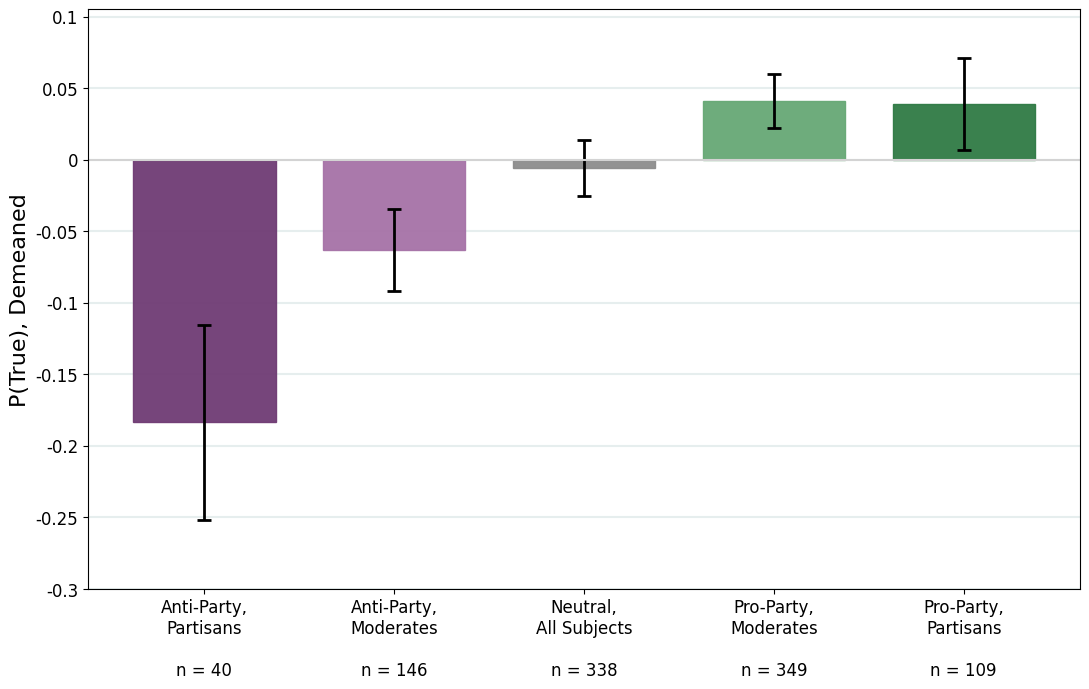

In [8]:
x = np.arange(len(summary))

colors = [
    "#6f3b74",
    "#a672a7",
    "#8c8c8c",
    "#66a875",
    "#2f7a44"
]

labels = [
    "Anti-Party,\nPartisans\n\nn = {:,}".format(int(summary.loc[0, "count"])),
    "Anti-Party,\nModerates\n\nn = {:,}".format(int(summary.loc[1, "count"])),
    "Neutral,\nAll Subjects\n\nn = {:,}".format(int(summary.loc[2, "count"])),
    "Pro-Party,\nModerates\n\nn = {:,}".format(int(summary.loc[3, "count"])),
    "Pro-Party,\nPartisans\n\nn = {:,}".format(int(summary.loc[4, "count"]))
]

overall_mean = plot_df["mean_prob_net"].mean()
summary["demeaned_mean"] = overall_mean - summary["mean"] 

plt.figure(figsize=(11, 7))

plt.bar(
    x,
    summary["demeaned_mean"],
    color=colors,
    edgecolor=colors,
    width=0.75,
    alpha=0.95
)

plt.errorbar(
    x,
    summary["demeaned_mean"],
    yerr=summary["ci95"],
    fmt="none",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    capthick=2
)

plt.axhline(0, color="lightgray", linewidth=1.5)

plt.xticks(x, labels, fontsize=12)
plt.yticks(
    [-0.30, -0.25, -0.20, -0.15, -0.10, -0.05, 0, 0.05, 0.10],
    ["-0.3", "-0.25", "-0.2", "-0.15", "-0.1", "-0.05", "0", "0.05", "0.1"],
    fontsize=12
)

plt.ylabel("P(True), Demeaned", fontsize=16)
plt.ylim(-0.3, 0.105)

plt.grid(axis="y", color="#e6eeee", linewidth=1.5)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()